In [158]:
import dotenv
import os
import pandas as pd
import irw
import polars as pl
import openai
import pairadigm as pdm
import mirt
dotenv.load_dotenv()

True

In [ ]:
# Pull all IRW tables that have item text available, age range is <=18, construct is cognitive/educational, measurement tool is test, item format is Likert/constructed response, and language is English
irw_edtexts = irw.fetch([
    'gilbert_meta_23',
    'gilbert_meta_102',
    'gilbert_meta_103',
    'gilbert_meta_104',
    'gilbert_meta_26',
    'gilbert_meta_2',
    # 'preschool_sel_akt', # Removed because the items also imply a picture was used which is not available to us
    'frac20'
])

In [153]:
for df in irw_edtexts.values():
    print(pl.DataFrame(df)['resp'].value_counts())

shape: (2, 2)
┌──────┬───────┐
│ resp ┆ count │
│ ---  ┆ ---   │
│ i64  ┆ u32   │
╞══════╪═══════╡
│ 1    ┆ 33230 │
│ 0    ┆ 30410 │
└──────┴───────┘
shape: (2, 2)
┌──────┬───────┐
│ resp ┆ count │
│ ---  ┆ ---   │
│ i64  ┆ u32   │
╞══════╪═══════╡
│ 1    ┆ 38791 │
│ 0    ┆ 29747 │
└──────┴───────┘
shape: (2, 2)
┌──────┬───────┐
│ resp ┆ count │
│ ---  ┆ ---   │
│ i64  ┆ u32   │
╞══════╪═══════╡
│ 1    ┆ 25052 │
│ 0    ┆ 28414 │
└──────┴───────┘
shape: (2, 2)
┌──────┬───────┐
│ resp ┆ count │
│ ---  ┆ ---   │
│ i64  ┆ u32   │
╞══════╪═══════╡
│ 1    ┆ 8698  │
│ 0    ┆ 8105  │
└──────┴───────┘
shape: (2, 2)
┌──────┬───────┐
│ resp ┆ count │
│ ---  ┆ ---   │
│ i64  ┆ u32   │
╞══════╪═══════╡
│ 0    ┆ 11235 │
│ 1    ┆ 12075 │
└──────┴───────┘
shape: (2, 2)
┌──────┬───────┐
│ resp ┆ count │
│ ---  ┆ ---   │
│ i64  ┆ u32   │
╞══════╪═══════╡
│ 0    ┆ 19624 │
│ 1    ┆ 23856 │
└──────┴───────┘
shape: (3, 2)
┌──────┬───────┐
│ resp ┆ count │
│ ---  ┆ ---   │
│ i64  ┆ u32   │
╞══════╪═══════╡
│

In [174]:
irw.itemtext("frac20")

"Item-level text is not available for table 'frac20'."

## Testing with gilbert_meta_23

In [110]:
df = irw_edtexts['gilbert_meta_103']
gilbert_for_testing = pl.DataFrame(df)
print(gilbert_for_testing.shape)
gilbert_for_testing.head()

(53466, 21)


id,item,resp,item_num,item_cov_transfer,rt,ln_rt,s_rt,i_rt,cluster_id,block_id,treat,cov_black,cov_male,cov_lep,cov_homelang_english,cov_iep,cov_ses_high,cov_ses_med,cov_ses_low,std_baseline
i64,str,i64,i64,str,str,str,f64,f64,i64,i64,i64,i64,i64,i64,str,i64,str,str,str,str
1545,"""cc_q18""",0,18,"""Mid""","""0.7740000262856483""","""-0.25618337143162456""",0.996693,2.344194,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272"""
1545,"""cc_q9""",0,9,"""Near""","""1.574000045657158""","""0.45362017900229995""",0.996693,2.65125,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272"""
1545,"""cc_q2""",0,2,"""Near""","""13.985000252723694""","""2.637985344724977""",0.996693,4.290656,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272"""
1545,"""cc_q31""",0,31,"""Far""","""0.9020000137388706""","""-0.10314074368794963""",0.996693,1.910889,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272"""
1545,"""cc_q4""",0,4,"""Near""","""1.2719999626278877""","""0.24059043553733855""",0.996693,3.080331,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272"""


In [111]:
gilbert_for_testing.select(pl.col('item').value_counts())

item
struct[2]
"{""cc_q22"",1824}"
"{""cc_q26"",1798}"
"{""cc_q21"",1831}"
"{""cc_q4"",1905}"
"{""cc_q28"",1789}"
…
"{""cc_q23"",1820}"
"{""cc_q20"",1833}"
"{""cc_q19"",1838}"


In [112]:
text = irw.itemtext("gilbert_meta_103")
text = pl.DataFrame(text)
print(text.shape)
text.head()

(174, 10)


table,section_id,item,instrument,instructions,section_prompt,item_text,option_text,resp_raw,resp
str,str,str,str,str,str,str,str,str,str
"""gilbert_meta_103""","""monkeys""","""cc_q10""","""reading comprehension""","""NA""","""1) A human is a primate. In pr…","""9. How did scientists know tha…","""NA""","""NA""","""0"""
"""gilbert_meta_103""","""monkeys""","""cc_q11""","""reading comprehension""","""NA""","""1) A human is a primate. In pr…","""10. What is this passage mostl…","""NA""","""NA""","""0"""
"""gilbert_meta_103""","""birds""","""cc_q14""","""reading comprehension""","""NA""","""1) Some birds that are here to…","""1. What is the main question t…","""NA""","""NA""","""0"""
"""gilbert_meta_103""","""birds""","""cc_q15""","""reading comprehension""","""NA""","""1) Some birds that are here to…","""2. Which sentence best summari…","""NA""","""NA""","""0"""
"""gilbert_meta_103""","""birds""","""cc_q16""","""reading comprehension""","""NA""","""1) Some birds that are here to…","""3. Scientists found that when …","""NA""","""NA""","""0"""


In [113]:
text_agg = text.group_by("item").agg(
    pl.col("section_prompt").first(),
    pl.col("item_text").first(),
    pl.col("option_text").filter(pl.col("option_text").is_not_null() & (pl.col("option_text") != "NA")).str.join("\n").alias("options")
).with_columns(
    pl.col("section_prompt").replace("NA", None),
    pl.col("item_text").replace("NA", None),
    pl.when(pl.col("options") == "").then(None).otherwise(pl.col("options")).alias("options")
).with_columns(
    pl.concat_str(
        [
            pl.concat_str([pl.col("section_prompt"), pl.col("item_text")], separator=": ", ignore_nulls=True),
            pl.col("options")
        ],
        separator="\n",
        ignore_nulls=True
    ).alias("combined_text")
).drop("options")

text_agg.write_csv("../data/processed/gilbert_meta_103_full-itemtext.csv")
print(text_agg.shape)
text_agg.head()

(29, 4)


item,section_prompt,item_text,combined_text
str,str,str,str
"""cc_q23""","""1) Some birds that are here to…","""10. In order to study the myst…","""1) Some birds that are here to…"
"""cc_q11""","""1) A human is a primate. In pr…","""10. What is this passage mostl…","""1) A human is a primate. In pr…"
"""cc_q10""","""1) A human is a primate. In pr…","""9. How did scientists know tha…","""1) A human is a primate. In pr…"
"""cc_q4""","""1) A human is a primate. In pr…","""3. What medical mystery are sc…","""1) A human is a primate. In pr…"
"""cc_q33""","""1) In many ways, skyscrapers a…","""8. A skyscraper has a command …","""1) In many ways, skyscrapers a…"


In [114]:
gilbert_for_testing_merge = gilbert_for_testing.join(
    text_agg, 
    on=["item"], 
    how="left"
)
print(gilbert_for_testing_merge.shape)
gilbert_for_testing_merge.head()

(53466, 24)


id,item,resp,item_num,item_cov_transfer,rt,ln_rt,s_rt,i_rt,cluster_id,block_id,treat,cov_black,cov_male,cov_lep,cov_homelang_english,cov_iep,cov_ses_high,cov_ses_med,cov_ses_low,std_baseline,section_prompt,item_text,combined_text
i64,str,i64,i64,str,str,str,f64,f64,i64,i64,i64,i64,i64,i64,str,i64,str,str,str,str,str,str,str
1545,"""cc_q18""",0,18,"""Mid""","""0.7740000262856483""","""-0.25618337143162456""",0.996693,2.344194,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) Some birds that are here to…","""5. What is the main idea of th…","""1) Some birds that are here to…"
1545,"""cc_q9""",0,9,"""Near""","""1.574000045657158""","""0.45362017900229995""",0.996693,2.65125,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) A human is a primate. In pr…","""8. Structure means""","""1) A human is a primate. In pr…"
1545,"""cc_q2""",0,2,"""Near""","""13.985000252723694""","""2.637985344724977""",0.996693,4.290656,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) A human is a primate. In pr…","""1. According to the passage, w…","""1) A human is a primate. In pr…"
1545,"""cc_q31""",0,31,"""Far""","""0.9020000137388706""","""-0.10314074368794963""",0.996693,1.910889,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) In many ways, skyscrapers a…","""6. To send a signal can also m…","""1) In many ways, skyscrapers a…"
1545,"""cc_q4""",0,4,"""Near""","""1.2719999626278877""","""0.24059043553733855""",0.996693,3.080331,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) A human is a primate. In pr…","""3. What medical mystery are sc…","""1) A human is a primate. In pr…"


### pairadigm

In [115]:
cgcot_prompts = [
    "Summarize the core task, question, behavioral statement, or scenario presented in this item. Item text: {text}",
    "Identify the primary knowledge domain, skill, clinical symptom, attitudinal belief, or psychological construct this item is attempting to measure and give a concise justification. Text: {text}",
    "Analyze the demand or severity of this item. For cognitive/ability items, does it require recall, multi-step reasoning, or synthesis? For psychological/attitudinal items, does endorsing it require a severe level of a symptom, a strongly held belief, or deep introspection? CONCISELY identify any structural or semantic elements—such as complex phrasing, tricky distractors, conditional logic, or strong emotional wording—that increase the cognitive load or the threshold for endorsement. Text: {text}",
    "Based on your analysis, describe the overall level of the underlying latent trait (e.g., high cognitive ability, severe psychological symptomology, strong attitude) required for a respondent to successfully answer or strongly endorse this item. Item text for reference: {text}"
]

In [116]:
text_agg_pd = text_agg.to_pandas()
text_agg_pd['combined_text'] = text_agg_pd['combined_text'].astype(str)
text_agg_pd.head()

,item,section_prompt,item_text,combined_text
0,cc_q23,1) Some birds that are here today are smaller ...,10. In order to study the mystery of change in...,1) Some birds that are here today are smaller ...
1,cc_q11,"1) A human is a primate. In primates, the hear...",10. What is this passage mostly about?,"1) A human is a primate. In primates, the hear..."
2,cc_q10,"1) A human is a primate. In primates, the hear...",9. How did scientists know that they successfu...,"1) A human is a primate. In primates, the hear..."
3,cc_q4,"1) A human is a primate. In primates, the hear...",3. What medical mystery are scientists trying ...,"1) A human is a primate. In primates, the hear..."
4,cc_q33,"1) In many ways, skyscrapers are like the huma...",8. A skyscraper has a command center. Another ...,"1) In many ways, skyscrapers are like the huma..."


In [159]:
MODEL_NAMES=["gemini-3-flash-preview", 'gpt-5.4-mini']
API_KEYS=[os.getenv("GEMINI_API_KEY"), os.getenv("OPENAI_API_KEY")]
BASE_URLS=[None, "https://us.api.openai.com/v1"]

p = pdm.Pairadigm(
    data=text_agg_pd, 
    item_id_name='item',
    text_name='combined_text',
    cgcot_prompts=cgcot_prompts, 
    model_name=MODEL_NAMES,
    api_key=API_KEYS,
    base_url=BASE_URLS,
    target_concept='underlying level of the targeted latent trait, ability, symptom severity, or attitude', 
    save_dir="../results/gilbert_meta_103_test_run"
)

In [160]:
p.test_clients_connection()

Testing LLM client connections using: 'What is the best restaurant in Detroit, MI?'...
  gemini-3-flash-preview: MODEL OK
  gpt-5.4-mini: MODEL OK


{'gemini-3-flash-preview': True, 'gpt-5.4-mini': True}

In [161]:
p.estimate_costs(
    custom_cost_per_1m_input=0.25, 
    custom_cost_per_1m_output=1.50
)


          LLM API COST ESTIMATION
DISCLAIMER: These are rough heuristics for token counting
and pricing based on general models. They do not reflect
real-time constraints, retries, or precise tokenizers.
------------------------------------------------------------
Client [0]: gemini-3-flash-preview
Pricing used: $0.250 per 1M input | $1.500 per 1M output
  [Breakdowns] Items: 29, Expected Input: ~65,036, Expected Output: ~23,200
  >>> Estimated Cost: $0.0511
------------------------------------------------------------
Client [1]: gpt-5.4-mini
Pricing used: $0.250 per 1M input | $1.500 per 1M output
  [Breakdowns] Items: 29, Expected Input: ~65,036, Expected Output: ~23,200
  >>> Estimated Cost: $0.0511
------------------------------------------------------------


In [162]:
p.generate_breakdowns(max_workers=32)


          LLM API COST ESTIMATION
DISCLAIMER: These are rough heuristics for token counting
and pricing based on general models. They do not reflect
real-time constraints, retries, or precise tokenizers.
------------------------------------------------------------
Client [0]: gemini-3-flash-preview
Pricing used: $0.500 per 1M input | $3.000 per 1M output
  [Breakdowns] Items: 29, Expected Input: ~65,036, Expected Output: ~23,200
  >>> Estimated Cost: $0.1021
------------------------------------------------------------
Client [1]: gpt-5.4-mini
Pricing used: $0.750 per 1M input | $4.500 per 1M output
  [Breakdowns] Items: 29, Expected Input: ~65,036, Expected Output: ~23,200
  >>> Estimated Cost: $0.1532
------------------------------------------------------------

Generating breakdowns for 29 items using: gemini-3-flash-preview


[gemini-3-flash-preview]: 100%|██████████| 29/29 [00:17<00:00,  1.65it/s]


Completed: 29/29 items

Generating breakdowns for 29 items using: gpt-5.4-mini


[gpt-5.4-mini]: 100%|██████████| 29/29 [00:04<00:00,  6.73it/s]

Completed: 29/29 items

Breakdowns added to [object].data — column(s): CGCoT_Breakdown_gemini-3-flash-preview, CGCoT_Breakdown_gpt-5.4-mini
Pairadigm saved to: ../results/gilbert_meta_103_test_run/
  Files written: metadata.json, data.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).
Auto-saved to: ../results/gilbert_meta_103_test_run


In [163]:
p.generate_pairings(num_pairs_per_item=15, breakdowns=True)

Pairwise DataFrame created and stored in self.pairwise_df


,item1,item2,breakdown1_gemini-3-flash-preview,breakdown2_gemini-3-flash-preview,breakdown1_gpt-5.4-mini,breakdown2_gpt-5.4-mini
0,cc_q2,cc_q20,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...
1,cc_q4,cc_q31,Original Text: 1) A human is a primate. In pri...,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) A human is a primate. In pri...,"Original Text: 1) In many ways, skyscrapers ar..."
2,cc_q18,cc_q9,Original Text: 1) Some birds that are here tod...,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...,Original Text: 1) A human is a primate. In pri...
3,cc_q10,cc_q14,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...
4,cc_q19,cc_q28,Original Text: 1) Some birds that are here tod...,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) Some birds that are here tod...,"Original Text: 1) In many ways, skyscrapers ar..."
...,...,...,...,...,...,...
233,cc_q22,cc_q15,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...
234,cc_q34,cc_q2,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) A human is a primate. In pri...,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) A human is a primate. In pri...
235,cc_q14,cc_q16,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...
236,cc_q20,cc_q28,Original Text: 1) Some birds that are here tod...,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) Some birds that are here tod...,"Original Text: 1) In many ways, skyscrapers ar..."


In [164]:
ex = p.pairwise_df['breakdown1_gemini-3-flash-preview'][0]

# textwrap ex
import textwrap
print(textwrap.fill(ex, width=80))

Original Text: 1) A human is a primate. In primates, the heart sends oxygen in
the blood all around the body. The body must have oxygen to function properly.
The strong heart muscle contracts to pump blood all around the body. A healthy
heart never rests.2) But what happens when a person’s heart gets weaker? People
with weak hearts need help. Scientists have to study a medical mystery. Then
they might be able to help people. 3) First, scientists need to diagnose the
reasons that a human heart gets weak. They need to do tests. But sometimes it
would be hard on a sick person to have tests done. So, scientists study animals
that have body systems like humans. Scientists knew that the macaque monkey’s
heart is similar to the human heart. So, they did tests with macaque monkeys.
The scientists learned what happens when a monkey has a heart attack. After a
heart attack, the monkey’s heart muscle has scar tissue where it was damaged.
The scar tissue cannot contract like a strong heart muscle 

In [165]:
p.generate_pairwise_annotations(max_workers=32)


          LLM API COST ESTIMATION
DISCLAIMER: These are rough heuristics for token counting
and pricing based on general models. They do not reflect
real-time constraints, retries, or precise tokenizers.
------------------------------------------------------------
Client [0]: gemini-3-flash-preview
Pricing used: $0.500 per 1M input | $3.000 per 1M output
  [Pairwise] Pairs: 238, Expected Input: ~472,668, Expected Output: ~11,900
  >>> Estimated Cost: $0.2720
------------------------------------------------------------
Client [1]: gpt-5.4-mini
Pricing used: $0.750 per 1M input | $4.500 per 1M output
  [Pairwise] Pairs: 238, Expected Input: ~349,384, Expected Output: ~11,900
  >>> Estimated Cost: $0.3156
------------------------------------------------------------


[gpt-5.4-mini] Pairwise comparisons: 100%|██████████| 238/238 [00:07<00:00, 29.85it/s]

Pairadigm saved to: ../results/gilbert_meta_103_test_run/
  Files written: metadata.json, data.parquet, pairwise_df.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).
Auto-saved to: ../results/gilbert_meta_103_test_run


,item1,item2,breakdown1_gemini-3-flash-preview,breakdown2_gemini-3-flash-preview,breakdown1_gpt-5.4-mini,breakdown2_gpt-5.4-mini,decision_gemini-3-flash-preview,justification_gemini-3-flash-preview,decision_gpt-5.4-mini,justification_gpt-5.4-mini
0,cc_q2,cc_q20,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...,Text2,FINAL ANSWER: <Description 2>\nJUSTIFICATION: ...,Text2,"FINAL ANSWER: ""Description 2""\n\nJUSTIFICATION..."
1,cc_q4,cc_q31,Original Text: 1) A human is a primate. In pri...,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) A human is a primate. In pri...,"Original Text: 1) In many ways, skyscrapers ar...",Text1,FINAL ANSWER: <Description 1>\nJUSTIFICATION: ...,Text1,"FINAL ANSWER: ""Description 1""\n\nJUSTIFICATION..."
2,cc_q18,cc_q9,Original Text: 1) Some birds that are here tod...,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...,Original Text: 1) A human is a primate. In pri...,Text1,"FINAL ANSWER: <""Description 1"">\nJUSTIFICATION...",Text1,"FINAL ANSWER: ""Description 1""\n\nJUSTIFICATION..."
3,cc_q10,cc_q14,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...,Text1,FINAL ANSWER: <Description 1>\nJUSTIFICATION: ...,Text2,"FINAL ANSWER: ""Description 2""\n\nJUSTIFICATION..."
4,cc_q19,cc_q28,Original Text: 1) Some birds that are here tod...,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) Some birds that are here tod...,"Original Text: 1) In many ways, skyscrapers ar...",Text1,FINAL ANSWER: <Description 1>\nJUSTIFICATION: ...,Text1,"FINAL ANSWER: ""Description 1"" \nJUSTIFICATION..."
...,...,...,...,...,...,...,...,...,...,...
233,cc_q22,cc_q15,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,Text1,FINAL ANSWER: Description 1\n\nJUSTIFICATION: ...,Text1,"FINAL ANSWER: ""Description 1""\n\nJUSTIFICATION..."
234,cc_q34,cc_q2,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) A human is a primate. In pri...,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) A human is a primate. In pri...,Text1,FINAL ANSWER: Description 1\n\nJUSTIFICATION: ...,Text2,"FINAL ANSWER: ""Description 2""\n\nJUSTIFICATION..."
235,cc_q14,cc_q16,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,Text1,FINAL ANSWER: <Description 1>\nJUSTIFICATION: ...,Text1,"FINAL ANSWER: ""Description 1""\n\nJUSTIFICATION..."
236,cc_q20,cc_q28,Original Text: 1) Some birds that are here tod...,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) Some birds that are here tod...,"Original Text: 1) In many ways, skyscrapers ar...",Text1,FINAL ANSWER: <Description 1>\n\nJUSTIFICATION...,Text1,"FINAL ANSWER: ""Description 1""\n\nJUSTIFICATION..."


In [ ]:
p.pairwise_df['decision_gemini-3-flash-preview'].value_counts()

decision_gemini-3-flash-preview
Text1    143
Text2     95
Name: count, dtype: int64

In [167]:
p.score_items(normalization_scale=(-3, 3), 
              decision_col="decision_gemini-3-flash-preview");
p.scored_df.head()

[gemini-3-flash-preview] Fitting Bradley-Terry model...
[gemini-3-flash-preview] Mean underlying level of the targeted latent trait, ability, symptom severity, or attitude score: 0.504
[gemini-3-flash-preview] Std  underlying level of the targeted latent trait, ability, symptom severity, or attitude score: 1.772

Summary statistics (Bradley_Terry_Score_gemini-3-flash-preview):
  mean: 0.504
  median: 0.659
  std: 1.772
  min: -3.000
  max: 3.000
  count: 29.000
Pairadigm saved to: ../results/gilbert_meta_103_test_run/
  Files written: metadata.json, data.parquet, pairwise_df.parquet, scored_df.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).
Auto-saved to: ../results/gilbert_meta_103_test_run


,item,section_prompt,item_text,combined_text,CGCoT_Breakdown_gemini-3-flash-preview,CGCoT_Breakdown_gpt-5.4-mini,Bradley_Terry_Score_gemini-3-flash-preview,Bradley_Terry_SE_gemini-3-flash-preview
0,cc_q23,1) Some birds that are here today are smaller ...,10. In order to study the mystery of change in...,1) Some birds that are here today are smaller ...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,-2.039452,0.330505
1,cc_q11,"1) A human is a primate. In primates, the hear...",10. What is this passage mostly about?,"1) A human is a primate. In primates, the hear...",Original Text: 1) A human is a primate. In pri...,Original Text: 1) A human is a primate. In pri...,2.243736,2.660056
2,cc_q10,"1) A human is a primate. In primates, the hear...",9. How did scientists know that they successfu...,"1) A human is a primate. In primates, the hear...",Original Text: 1) A human is a primate. In pri...,Original Text: 1) A human is a primate. In pri...,1.974583,2.123971
3,cc_q4,"1) A human is a primate. In primates, the hear...",3. What medical mystery are scientists trying ...,"1) A human is a primate. In primates, the hear...",Original Text: 1) A human is a primate. In pri...,Original Text: 1) A human is a primate. In pri...,1.945033,1.971132
4,cc_q33,"1) In many ways, skyscrapers are like the huma...",8. A skyscraper has a command center. Another ...,"1) In many ways, skyscrapers are like the huma...","Original Text: 1) In many ways, skyscrapers ar...","Original Text: 1) In many ways, skyscrapers ar...",-1.181234,0.458920


In [169]:
p.plot_score_distribution(score_col='Bradley_Terry_Score_gemini-3-flash-preview')

In [170]:
p.scored_df

,item,section_prompt,item_text,combined_text,CGCoT_Breakdown_gemini-3-flash-preview,CGCoT_Breakdown_gpt-5.4-mini,Bradley_Terry_Score_gemini-3-flash-preview,Bradley_Terry_SE_gemini-3-flash-preview
0,cc_q23,1) Some birds that are here today are smaller ...,10. In order to study the mystery of change in...,1) Some birds that are here today are smaller ...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,-2.039452,0.330505
1,cc_q11,"1) A human is a primate. In primates, the hear...",10. What is this passage mostly about?,"1) A human is a primate. In primates, the hear...",Original Text: 1) A human is a primate. In pri...,Original Text: 1) A human is a primate. In pri...,2.243736,2.660056
2,cc_q10,"1) A human is a primate. In primates, the hear...",9. How did scientists know that they successfu...,"1) A human is a primate. In primates, the hear...",Original Text: 1) A human is a primate. In pri...,Original Text: 1) A human is a primate. In pri...,1.974583,2.123971
3,cc_q4,"1) A human is a primate. In primates, the hear...",3. What medical mystery are scientists trying ...,"1) A human is a primate. In primates, the hear...",Original Text: 1) A human is a primate. In pri...,Original Text: 1) A human is a primate. In pri...,1.945033,1.971132
4,cc_q33,"1) In many ways, skyscrapers are like the huma...",8. A skyscraper has a command center. Another ...,"1) In many ways, skyscrapers are like the huma...","Original Text: 1) In many ways, skyscrapers ar...","Original Text: 1) In many ways, skyscrapers ar...",-1.181234,0.458920
5,cc_q26,"1) In many ways, skyscrapers are like the huma...","1. According to the passage, why does the auth...","1) In many ways, skyscrapers are like the huma...","Original Text: 1) In many ways, skyscrapers ar...","Original Text: 1) In many ways, skyscrapers ar...",-3.000000,0.194520
6,cc_q14,1) Some birds that are here today are smaller ...,1. What is the main question that scientists a...,1) Some birds that are here today are smaller ...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,1.701891,1.814417
7,cc_q18,1) Some birds that are here today are smaller ...,5. What is the main idea of this passage?,1) Some birds that are here today are smaller ...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,1.430026,1.532143
8,cc_q22,1) Some birds that are here today are smaller ...,9. What is this passage mostly about?,1) Some birds that are here today are smaller ...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,1.978681,2.147430
9,cc_q19,1) Some birds that are here today are smaller ...,"6. In paragraph 3, what is another word for di...",1) Some birds that are here today are smaller ...,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,2.589169,2.847167


### IRT

In [127]:
gilbert_for_testing_merge

id,item,resp,item_num,item_cov_transfer,rt,ln_rt,s_rt,i_rt,cluster_id,block_id,treat,cov_black,cov_male,cov_lep,cov_homelang_english,cov_iep,cov_ses_high,cov_ses_med,cov_ses_low,std_baseline,section_prompt,item_text,combined_text
i64,str,i64,i64,str,str,str,f64,f64,i64,i64,i64,i64,i64,i64,str,i64,str,str,str,str,str,str,str
1545,"""cc_q18""",0,18,"""Mid""","""0.7740000262856483""","""-0.25618337143162456""",0.996693,2.344194,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) Some birds that are here to…","""5. What is the main idea of th…","""1) Some birds that are here to…"
1545,"""cc_q9""",0,9,"""Near""","""1.574000045657158""","""0.45362017900229995""",0.996693,2.65125,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) A human is a primate. In pr…","""8. Structure means""","""1) A human is a primate. In pr…"
1545,"""cc_q2""",0,2,"""Near""","""13.985000252723694""","""2.637985344724977""",0.996693,4.290656,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) A human is a primate. In pr…","""1. According to the passage, w…","""1) A human is a primate. In pr…"
1545,"""cc_q31""",0,31,"""Far""","""0.9020000137388706""","""-0.10314074368794963""",0.996693,1.910889,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) In many ways, skyscrapers a…","""6. To send a signal can also m…","""1) In many ways, skyscrapers a…"
1545,"""cc_q4""",0,4,"""Near""","""1.2719999626278877""","""0.24059043553733855""",0.996693,3.080331,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) A human is a primate. In pr…","""3. What medical mystery are sc…","""1) A human is a primate. In pr…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
575,"""cc_q8""",0,8,"""Near""","""145.3260040283203""","""4.978979522411443""",3.565902,2.873496,98,21,1,0,0,0,"""0""",0,"""0""","""0""","""1""","""-0.9303783774375916""","""1) A human is a primate. In pr…","""7. The author of this article …","""1) A human is a primate. In pr…"
575,"""cc_q14""",0,14,"""Mid""","""42.22699999809265""","""3.7430598268319084""",3.565902,3.999676,98,21,1,0,0,0,"""0""",0,"""0""","""0""","""1""","""-0.9303783774375916""","""1) Some birds that are here to…","""1. What is the main question t…","""1) Some birds that are here to…"
575,"""cc_q5""",1,5,"""Near""","""23.847999572753906""","""3.1717003384603855""",3.565902,2.829076,98,21,1,0,0,0,"""0""",0,"""0""","""0""","""1""","""-0.9303783774375916""","""1) A human is a primate. In pr…","""4. Why do scientists study mon…","""1) A human is a primate. In pr…"


In [128]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def fit_2pl(df, id_col='id', item_col='item', resp_col='resp',
            reg_theta=1e-2, reg_loga=1e-3, reg_b=1e-3, maxiter=1000, eps=1e-6):
    if not isinstance(df, pd.DataFrame):
        df = df.to_pandas()

    ids = df[id_col].astype(str).unique()
    items = df[item_col].astype(str).unique()
    pid_map = {v:i for i,v in enumerate(ids)}
    iid_map = {v:i for i,v in enumerate(items)}

    person_idx = df[id_col].astype(str).map(pid_map).to_numpy(dtype=int)
    item_idx = df[item_col].astype(str).map(iid_map).to_numpy(dtype=int)
    y = df[resp_col].to_numpy(dtype=float)

    nP = len(ids); nI = len(items)

    # init (clip probabilities to avoid 0/1)
    person_score = np.bincount(person_idx, weights=y, minlength=nP)
    person_count = np.bincount(person_idx, minlength=nP)
    p_person = np.where(person_count>0, person_score / person_count, 0.5)
    p_person = np.clip(p_person, eps, 1 - eps)
    theta0 = np.clip(np.log(p_person / (1 - p_person)), -3, 3)

    item_score = np.bincount(item_idx, weights=y, minlength=nI)
    item_count = np.bincount(item_idx, minlength=nI)
    p_item = np.where(item_count>0, item_score / item_count, 0.5)
    p_item = np.clip(p_item, eps, 1 - eps)
    b0 = -np.log(p_item / (1 - p_item))
    loga0 = np.zeros(nI)  # log(1)

    x0 = np.concatenate([theta0, loga0, b0])

    def nll(params):
        thetas = params[:nP]
        loga = params[nP:nP+nI]
        b = params[nP+nI:]
        a = np.exp(loga)
        x = a[item_idx] * (thetas[person_idx] - b[item_idx])
        ll = y * (-np.logaddexp(0, -x)) + (1-y) * (-np.logaddexp(0, x))
        neg_ll = -ll.sum()
        neg_ll += reg_theta * np.sum(thetas**2) + reg_loga * np.sum(loga**2) + reg_b * np.sum(b**2)
        return neg_ll

    # removed deprecated 'disp' option
    res = minimize(nll, x0, method='L-BFGS-B', options={'maxiter': maxiter})
    params = res.x
    thetas = params[:nP]
    loga = params[nP:nP+nI]
    b = params[nP+nI:]
    a = np.exp(loga)

    m = thetas.mean()
    s = thetas.std(ddof=0) if thetas.std(ddof=0)>0 else 1.0
    thetas_z = (thetas - m) / s
    b_z = (b - m) / s

    persons_df = pd.DataFrame({id_col: ids, 'theta': thetas_z})
    items_df = pd.DataFrame({item_col: items, 'a': a, 'b': b_z})

    return persons_df, items_df, res

# Example usage:
persons, items, opt_res = fit_2pl(gilbert_for_testing_merge, id_col='id', item_col='item', resp_col='resp')
print(items.head())
print(persons.head())

     item         a         b
0  cc_q18  2.039988 -0.488296
1   cc_q9  1.672480 -0.238121
2   cc_q2  0.675436 -0.098813
3  cc_q31  1.757331 -0.499038
4   cc_q4  1.168699  0.198326
     id     theta
0  1545 -1.374193
1   193  0.634159
2   365 -0.197006
3  1679 -0.454728
4   423  0.130069


In [139]:
import numpy as np
import pandas as pd
import mirt

def fit_2pl_mirt(
    df,
    id_col="id",
    item_col="item",
    resp_col="resp",
    n_quadpts=21,
    max_iter=500,
    tol=1e-4,
    score_method="EAP",
    use_rust=True,
    verbose=False,
):
    # Accept polars or pandas input
    if not isinstance(df, pd.DataFrame):
        df = df.to_pandas()

    x = df[[id_col, item_col, resp_col]].dropna().copy()
    x[resp_col] = x[resp_col].astype(int)

    bad = set(x[resp_col].unique()) - {0, 1}
    if bad:
        raise ValueError(f"{resp_col} must be binary (0/1). Found: {sorted(bad)}")

    # Guard against duplicate person-item rows
    dup_mask = x.duplicated([id_col, item_col], keep=False)
    if dup_mask.any():
        n_dup = int(dup_mask.sum())
        raise ValueError(
            f"Found {n_dup} duplicate person-item rows. "
            "Resolve duplicates before fitting mirt."
        )

    # Stable coding so joins/merges are predictable
    person_codes, person_labels = pd.factorize(x[id_col], sort=True)
    item_codes, item_labels = pd.factorize(x[item_col], sort=True)

    n_persons = len(person_labels)
    n_items = len(item_labels)

    # mirt expects 2D matrix: rows=persons, cols=items; missing coded as -1
    responses = np.full((n_persons, n_items), -1, dtype=np.int32)
    responses[person_codes, item_codes] = x[resp_col].to_numpy(dtype=np.int32)

    fit_result = mirt.fit_mirt(
        responses,
        model="2PL",
        n_quadpts=n_quadpts,
        max_iter=max_iter,
        tol=tol,
        verbose=verbose,
        item_names=item_labels.astype(str).tolist(),
        use_rust=use_rust,
    )

    # Person scores (theta + SE)
    score_result = mirt.fscores(
        fit_result,
        responses,
        method=score_method,
        person_ids=person_labels.tolist(),
        n_quadpts=n_quadpts,
    )

    # mirt may return pandas or polars depending on backend
    scores_df = score_result.to_dataframe()
    if hasattr(scores_df, "to_pandas"):  # polars DataFrame
        persons_df = scores_df.to_pandas()
    else:  # pandas DataFrame
        persons_df = scores_df.copy()

    # Keep person id as a normal column
    if "person" in persons_df.columns:
        persons_df = persons_df.rename(columns={"person": id_col})
    elif id_col not in persons_df.columns:
        persons_df = persons_df.reset_index()
        if "index" in persons_df.columns:
            persons_df = persons_df.rename(columns={"index": id_col})

    # Item parameters
    params = fit_result.model.parameters
    a = np.asarray(params["discrimination"]).ravel()
    b = np.asarray(params["difficulty"]).ravel()

    items_df = pd.DataFrame(
        {
            item_col: item_labels.tolist(),
            "a": a,
            "b": b,
        }
    )

    return persons_df, items_df, fit_result, score_result, responses

In [143]:
persons, items, fit_res, score_res, resp_matrix = fit_2pl_mirt(
    gilbert_for_testing_merge,
    id_col="id",
    item_col="item",
    resp_col="resp",
    n_quadpts=21,
    max_iter=500,
    tol=1e-4,
    score_method="EAP",
    use_rust=False
)

print(fit_res.summary())
print(items.head())
print(persons.head())

                               IRT Model Results                                
Model:              2PL                  Log-Likelihood:     -34755.8269
No. Items:          29                   AIC:                 69627.6537
No. Factors:        1                    BIC:                 69949.9569
No. Persons:        1914                 No. Parameters:              58
Converged:          True                 Iterations:                  35
--------------------------------------------------------------------------------

discrimination:
Item              Estimate    Std.Err    z-value      P>|z|     [95%      CI]
--------------------------------------------------------------------------------
cc_q10              1.3062     0.0756     17.281     0.0000   1.1580   1.4543
cc_q11              1.7724     0.0930     19.050     0.0000   1.5901   1.9548
cc_q14              1.4372     0.0848     16.953     0.0000   1.2710   1.6033
cc_q15              0.6761     0.0454     14.896     0.0000   0

In [144]:
all_item_scores = p.scored_df.merge(items, on='item').copy()
all_item_scores.head()

,item,section_prompt,item_text,combined_text,CGCoT_Breakdown,Bradley_Terry_Score,Bradley_Terry_SE,a,b
0,cc_q23,1) Some birds that are here today are smaller ...,10. In order to study the mystery of change in...,1) Some birds that are here today are smaller ...,Original Text: 1) Some birds that are here tod...,-1.872741,0.487011,1.851153,-0.279750
1,cc_q11,"1) A human is a primate. In primates, the hear...",10. What is this passage mostly about?,"1) A human is a primate. In primates, the hear...",Original Text: 1) A human is a primate. In pri...,2.528321,3.351224,1.772447,-0.073814
2,cc_q10,"1) A human is a primate. In primates, the hear...",9. How did scientists know that they successfu...,"1) A human is a primate. In primates, the hear...",Original Text: 1) A human is a primate. In pri...,3.000000,4.015348,1.306181,0.186763
3,cc_q4,"1) A human is a primate. In primates, the hear...",3. What medical mystery are scientists trying ...,"1) A human is a primate. In primates, the hear...",Original Text: 1) A human is a primate. In pri...,2.703877,3.204296,1.499753,0.144564
4,cc_q33,"1) In many ways, skyscrapers are like the huma...",8. A skyscraper has a command center. Another ...,"1) In many ways, skyscrapers are like the huma...","Original Text: 1) In many ways, skyscrapers ar...",-2.552565,0.388177,2.057368,-0.497265


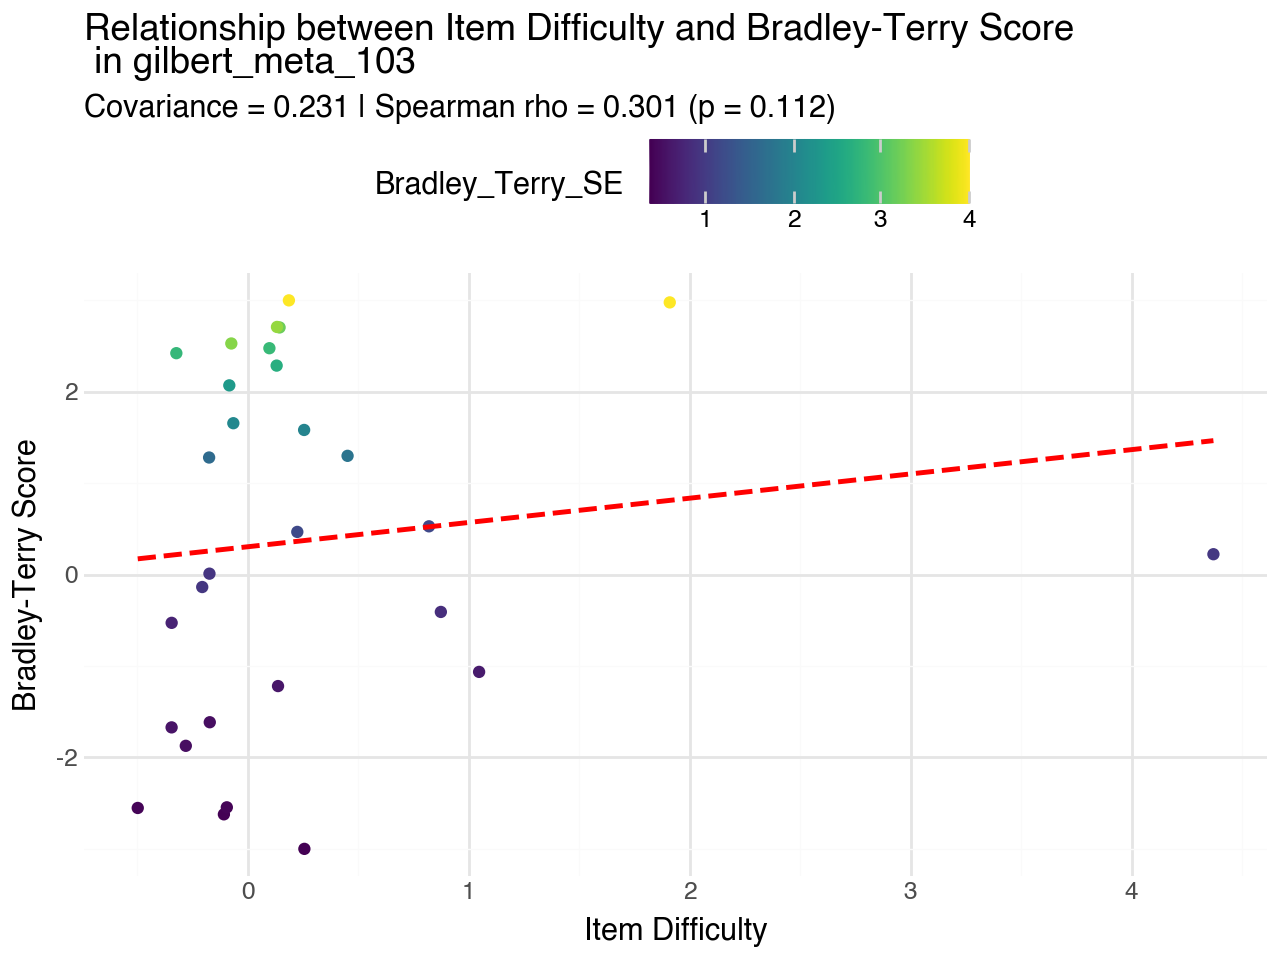

In [145]:
from scipy.stats import spearmanr
from plotnine import ggplot, aes, geom_point, geom_smooth, theme_minimal, labs, theme

# Keep only non-missing values for both variables
plot_df = all_item_scores[['b', 'Bradley_Terry_Score', 'Bradley_Terry_SE']].dropna()

# Compute metrics
covariance = plot_df['b'].cov(plot_df['Bradley_Terry_Score'])
spearman_rho, spearman_p = spearmanr(plot_df['b'], plot_df['Bradley_Terry_Score'])

subtitle_txt = (
    f"Covariance = {covariance:.3f} | "
    f"Spearman rho = {spearman_rho:.3f} (p = {spearman_p:.3g})"
)

(
    ggplot(plot_df, aes(x='b', y='Bradley_Terry_Score'))
    + geom_point(aes(color='Bradley_Terry_SE'))
    + geom_smooth(method='lm', se=False, color='red', linetype='dashed')
    + theme_minimal()
    + theme(legend_position='top')
    + labs(
        title='Relationship between Item Difficulty and Bradley-Terry Score\n in gilbert_meta_103',
        subtitle=subtitle_txt,
        x='Item Difficulty',
        y='Bradley-Terry Score'
    )
)

In [148]:
items.describe().to_dict()

{'a': {'count': 29.0,
  'mean': 1.4481025904427722,
  'std': 0.5474529340026157,
  'min': 0.23041806997854378,
  '25%': 1.0716445822648362,
  '50%': 1.4997528459190845,
  '75%': 1.8511527114026076,
  'max': 2.4224232543366395},
 'b': {'count': 29.0,
  'mean': 0.27964727731247596,
  'std': 0.9326945807231708,
  'min': -0.497264742957712,
  '25%': -0.17275600236804442,
  '50%': 0.09851361183283948,
  '75%': 0.2556541083829428,
  'max': 4.370457841990816}}